In [10]:
import os
import tensorflow as tf
import tensorflow.keras
import matplotlib.pyplot as plt
import librosa
import numpy as np

In [22]:
file_path = "C:/Users/Sucheth Katte/Downloads/release_in_the_wild/real/992.wav"

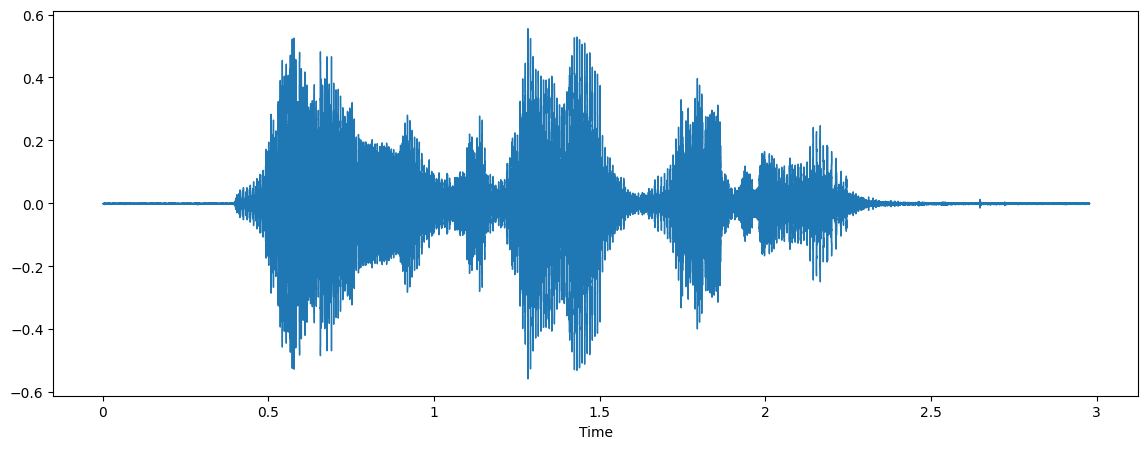

In [23]:
x, sr = librosa.load(file_path, sr=44100)
plt.figure(figsize=(14,5))
librosa.display.waveshow(x, sr=sr)

In [7]:
from IPython.display import Audio
Audio(data=x, rate = sr)

# Visualising CHUNKS of audio

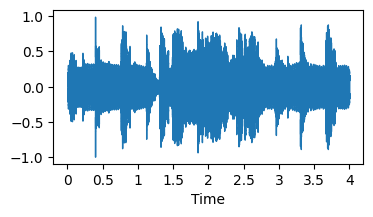

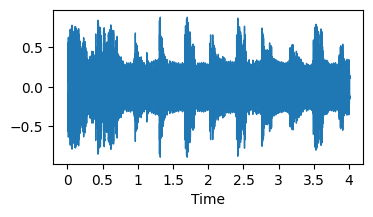

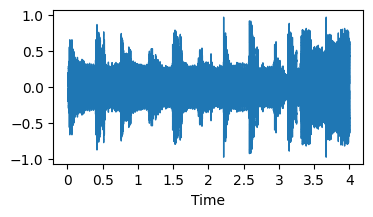

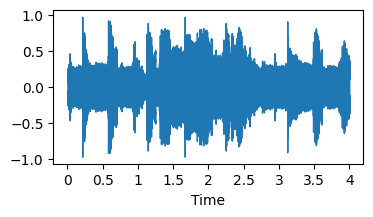

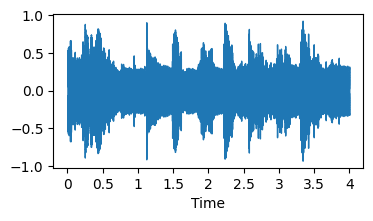

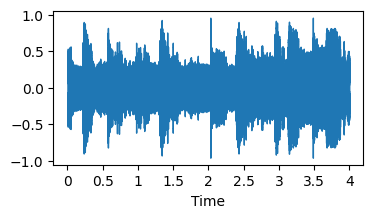

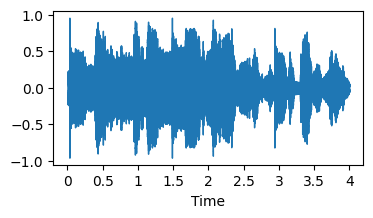

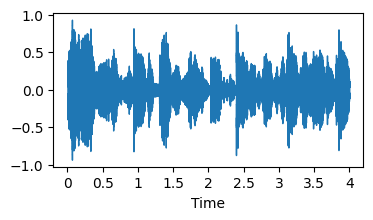

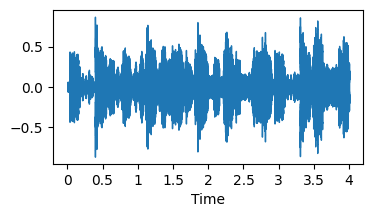

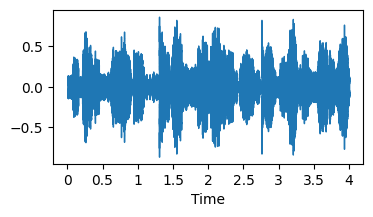

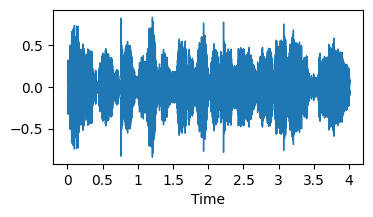

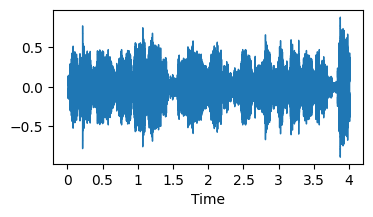

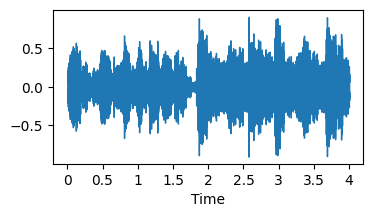

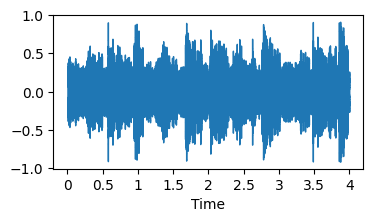

In [14]:
audio_path = "./IEEE content/Audio_Data/train/aegir_27/aegir_27_0.wav"
wav, sr = librosa.load(audio_path, sr=None) #sr = None to keep original sampling rate

chunk_duration = 4
overlap_duration = 2

chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr

num_chunks = int(np.ceil((len(wav) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

for i in range(num_chunks):
    start =  i * (chunk_samples - overlap_samples)
    end = start + chunk_samples

    chunk = wav[start:end]
    plt.figure(figsize=(4,2))
    librosa.display.waveshow(chunk, sr=sr)
    plt.show()

## Divided into chunks so that it's easier to understand for the NN

# Melspectogram Visualization

In [61]:
def plot_melespectrogram(y,sr):
    spectrogram = librosa.feature.melspectrogram(y=y,sr=sr)
    spectrogram_db = librosa.power_to_db(spectrogram,ref=np.max)
    plt.figure(figsize=(10,4))
    librosa.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
    plt.colorbar(format='%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()
    

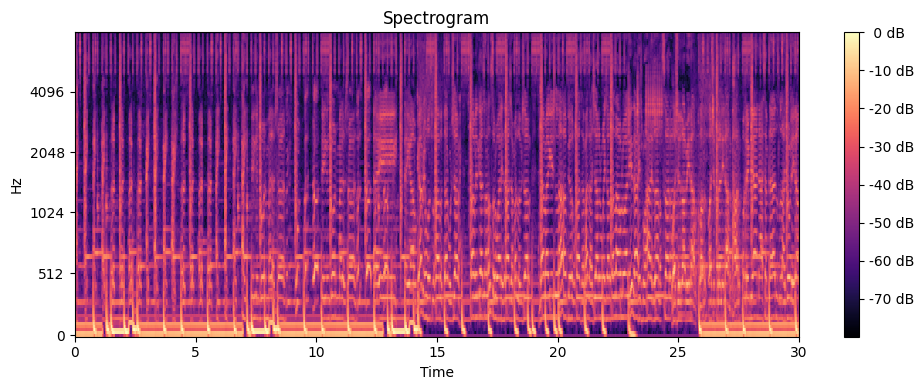

In [16]:
plot_melespectrogram(wav,sr)

This does not give good information about the audio (looks like random noise)

In [62]:
def plot_melspectrogram_chunks(y,sr):
    chunk_duration = 4
    overlap_duration = 2
    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr
    num_chunks = int(np.ceil((len(y)-chunk_samples)/(chunk_samples-overlap_samples)))+1
    for i in range(num_chunks):
        start = i*(chunk_samples-overlap_samples)
        end = start+chunk_samples
        chunk = y[start:end]
        spectrogram = librosa.feature.melspectrogram(y=chunk,sr=sr)
        print(spectrogram.shape)
        spectrogram_db = librosa.power_to_db(spectrogram,ref=np.max)
        plt.figure(figsize=(10,4))
        librosa.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
        plt.colorbar(format='%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()

(128, 126)


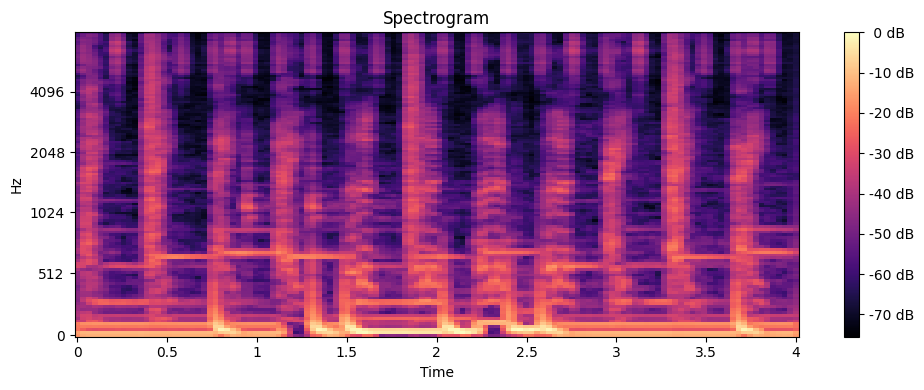

(128, 126)


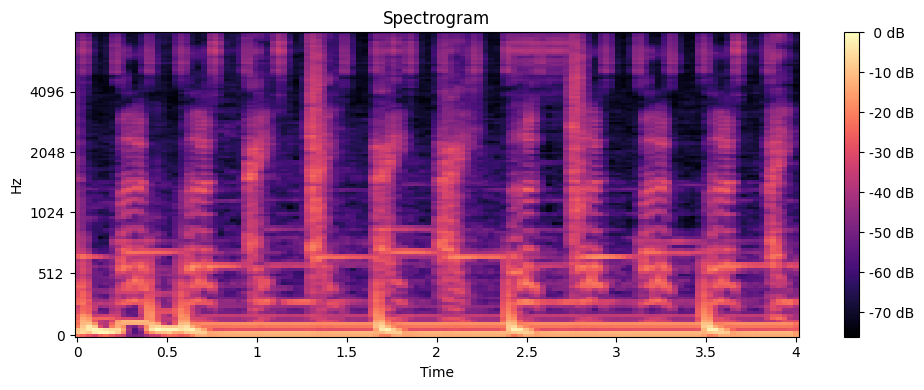

(128, 126)


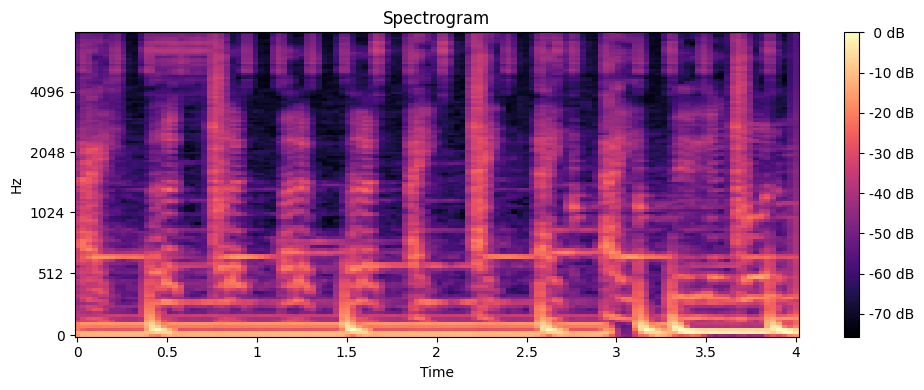

(128, 126)


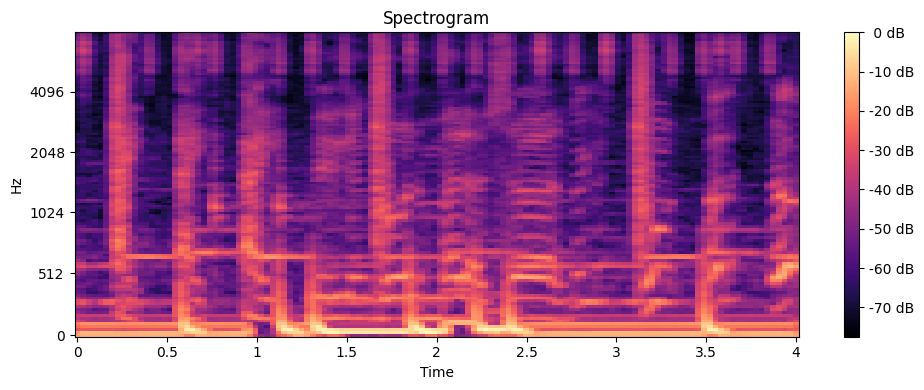

(128, 126)


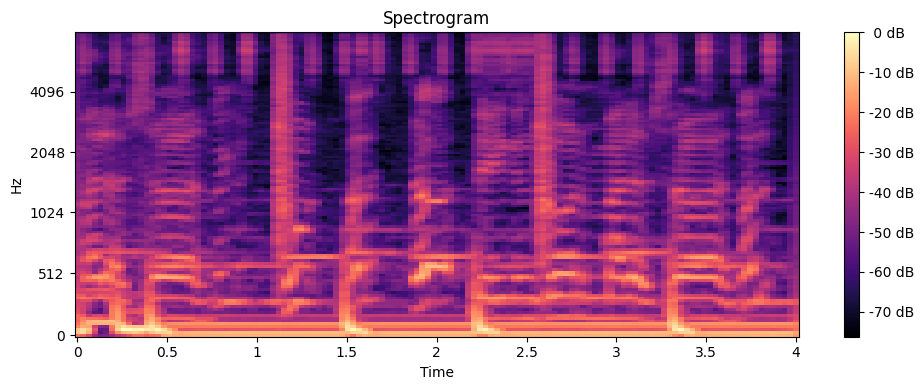

(128, 126)


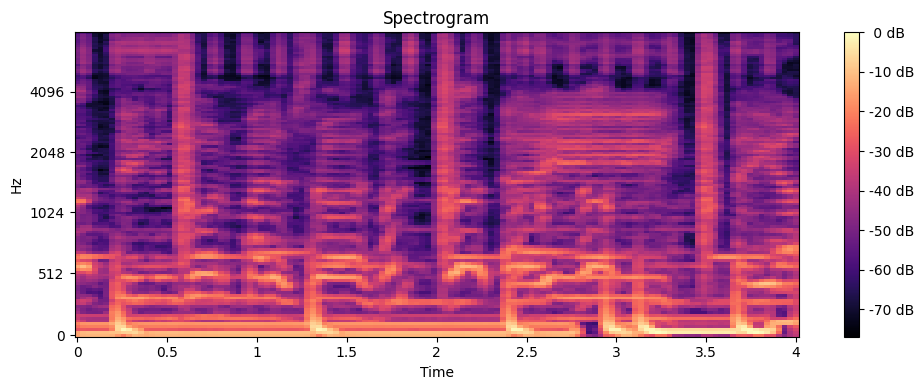

(128, 126)


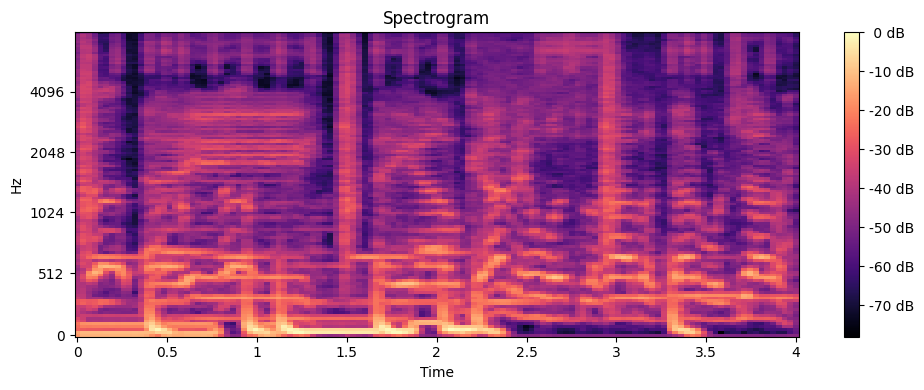

(128, 126)


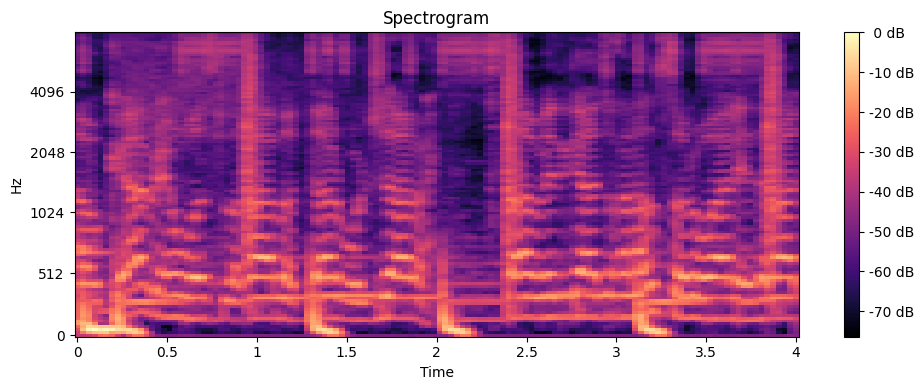

(128, 126)


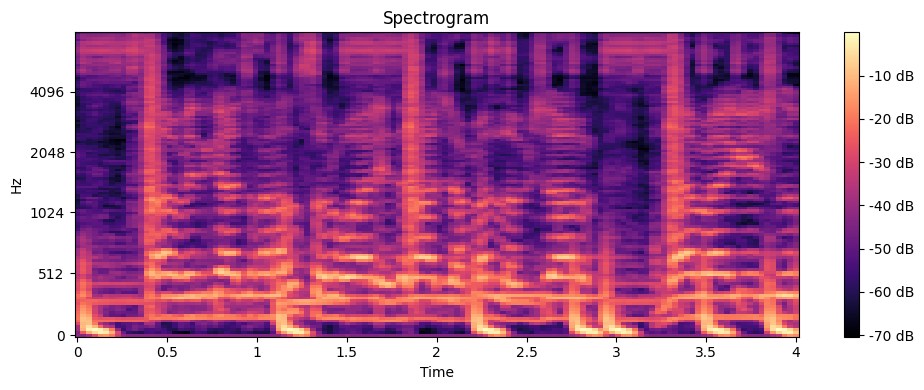

(128, 126)


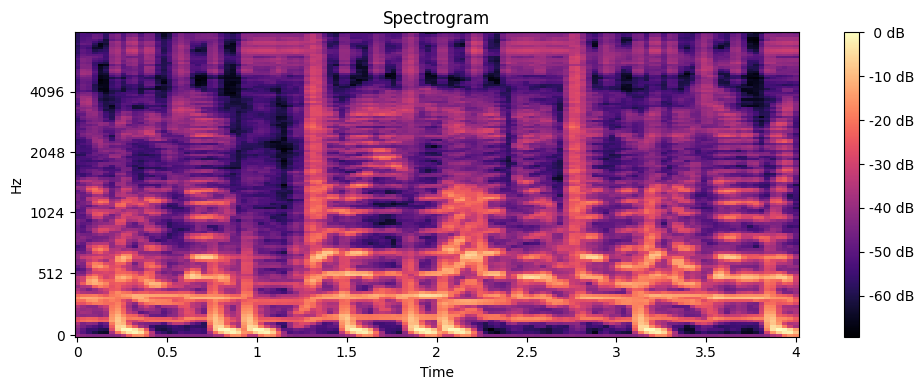

(128, 126)


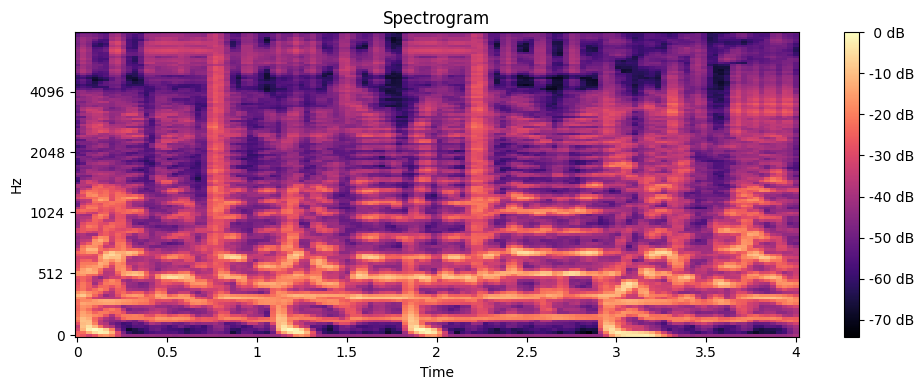

(128, 126)


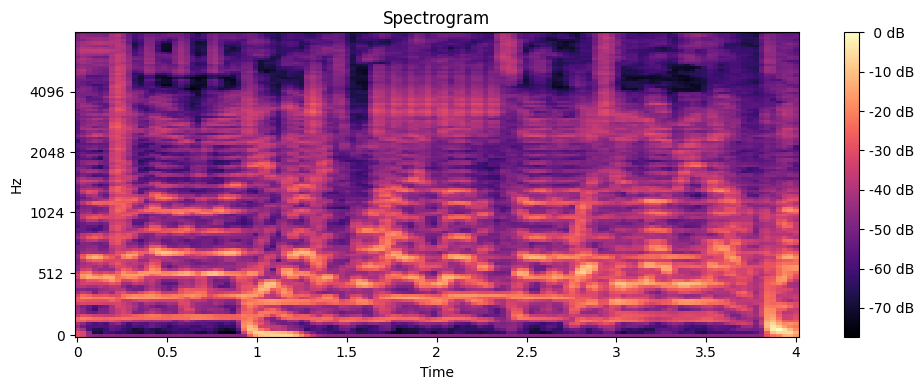

(128, 126)


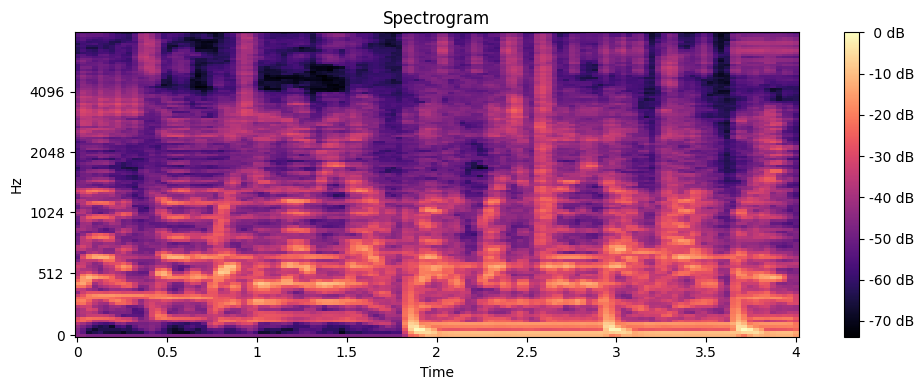

(128, 126)


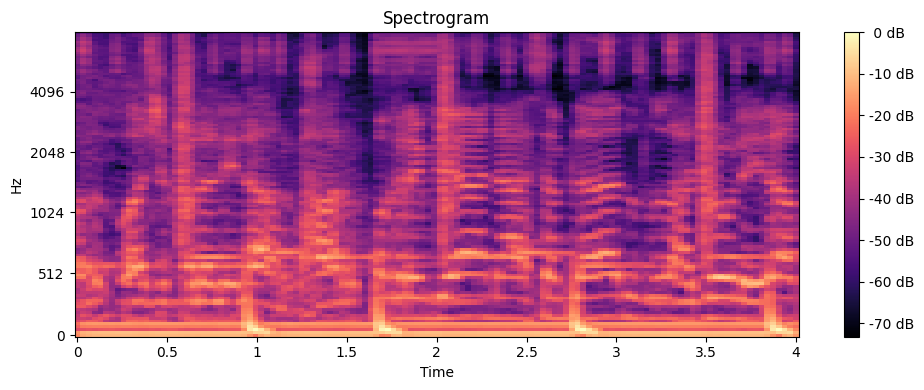

In [18]:
plot_melspectrogram_chunks(wav,sr)

This gives a better idea to the NN

# Data Preprocessing

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

def split_data_dir(base_dir, test_size=0.2, seed=42):
    """
    Scans through all subfolders in base_dir and creates train/test lists of file paths.
    """
    class_names = sorted(os.listdir(base_dir))
    train_files, test_files = [], []
    train_labels, test_labels = [], []

    for i_class, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        # Get all .wav files
        files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith('.wav')]
        if not files:
            continue

        # Split
        train, test = train_test_split(files, test_size=test_size, random_state=seed)
        train_files.extend(train)
        test_files.extend(test)
        train_labels.extend([i_class] * len(train))
        test_labels.extend([i_class] * len(test))

    return (train_files, train_labels), (test_files, test_labels), class_names


In [ ]:
from tensorflow.image import resize
import librosa, numpy as np
import tensorflow as tf

def load_and_preprocess_files(file_list, label_list, target_shape=(128, 344), sample_rate=16000):
    data, labels = [], []

    for file_path, i_class in zip(file_list, label_list):
        # --- Load audio uniformly ---
        audio_data, sr = librosa.load(file_path, sr=sample_rate, mono=True)

        # --- Normalize amplitude ---
        audio_data = librosa.util.normalize(audio_data)

        # --- Chunking ---
        chunk_duration = 4  # seconds
        overlap_duration = 2  # seconds
        chunk_samples = chunk_duration * sample_rate
        overlap_samples = overlap_duration * sample_rate

        if len(audio_data) < chunk_samples:
            audio_data = np.pad(audio_data, (0, chunk_samples - len(audio_data)))

        num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

        for i in range(num_chunks):
            start = i * (chunk_samples - overlap_samples)
            end = start + chunk_samples
            chunk = audio_data[start:end]

            # --- Feature extraction (Mel-spectrogram) ---
            mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sample_rate, n_mels=128)
            mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # --- Resize for CNN input ---
            mel_spectrogram_db = resize(
                np.expand_dims(mel_spectrogram_db, axis=-1), target_shape
            ).numpy()

            data.append(mel_spectrogram_db)
            labels.append(i_class)

    data = np.array(data)
    labels = np.array(labels)
    print(f"✅ Loaded {len(data)} samples")
    return data, labels


In [11]:
data_dir = "C:/Users/Sucheth Katte/Downloads/release_in_the_wild"
classes = ['real', 'fake']

In [ ]:
from tensorflow.image import resize

def load_and_preprocess_data(data_dir, classes, target_shape=(128, 344), sample_rate=16000):
    data = []
    labels = []

    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print(f"Processing {class_name} ...")

        for filename in os.listdir(class_dir):
            if not filename.endswith('.wav'):
                continue

            file_path = os.path.join(class_dir, filename)

            # --- Load audio uniformly ---
            audio_data, sr = librosa.load(file_path, sr=sample_rate, mono=True)

            # --- Normalize amplitude ---
            audio_data = librosa.util.normalize(audio_data)

            # --- Chunking ---
            chunk_duration = 4  # seconds
            overlap_duration = 2  # seconds
            chunk_samples = chunk_duration * sample_rate
            overlap_samples = overlap_duration * sample_rate

            if len(audio_data) < chunk_samples:
                # pad short clips
                audio_data = np.pad(audio_data, (0, chunk_samples - len(audio_data)))

            num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

            for i in range(num_chunks):
                start = i * (chunk_samples - overlap_samples)
                end = start + chunk_samples
                chunk = audio_data[start:end]

                # --- Feature extraction (Mel-spectrogram) ---
                mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sample_rate, n_mels=128)
                mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

                # --- Resize for CNN input ---
                mel_spectrogram_db = resize(
                    np.expand_dims(mel_spectrogram_db, axis=-1), target_shape
                ).numpy()

                data.append(mel_spectrogram_db)
                labels.append(i_class)

    data = np.array(data)
    labels = np.array(labels)
    print(f"✅ Loaded {len(data)} samples")
    return data, labels


In [ ]:
base_dir = "data"  # your single folder

(train_files, train_labels), (test_files, test_labels), classes = split_data_dir(base_dir)

X_train, y_train = load_and_preprocess_files(train_files, train_labels)
X_test, y_test = load_and_preprocess_files(test_files, test_labels)


In [13]:
data,labels = load_and_preprocess_data(data_dir,classes)

Processing-- real
Processing-- fake


In [14]:
data.shape

(51922, 128, 344, 1)

In [15]:
labels.shape

(51922,)

In [16]:
from tensorflow.keras.utils import to_categorical

labels = to_categorical(labels, num_classes = len(classes))
labels

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], shape=(51922, 2))

In [17]:
labels.shape

(51922, 2)

In [ ]:
file_path = "C:/Users/Sucheth Katte/Downloads/release_in_the_wild/real/992.wav"
y, sr = librosa.load(file_path, sr=16000)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Raw Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


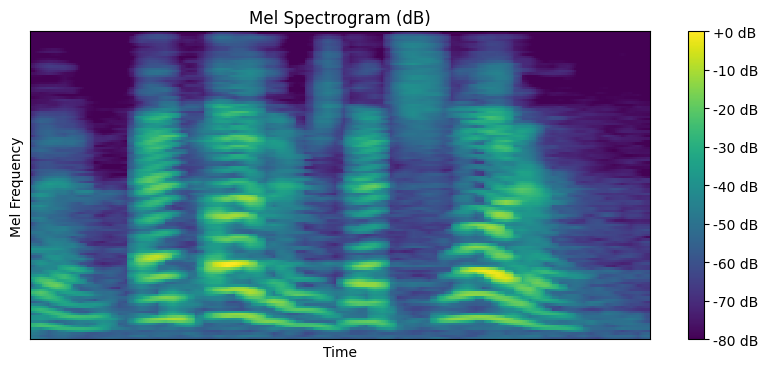

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

test_spec = data[10].squeeze()

plt.figure(figsize=(10, 4))
librosa.display.specshow(test_spec, sr=sr, hop_length=512, cmap='viridis')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram (already in dB scale)")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.show()




In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(data,labels,test_size=0.2,random_state=42)

In [ ]:
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout
from tensorflow.keras.optimizers.legacy import Adam

model = tf.keras.models.Sequential()

model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=X_train[0].shape))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Dropout(0.3))

model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(units=1200,activation='relu'))
model.add(Dropout(0.45))

model.add(Dense(units=len(classes),activation='softmax'))

In [52]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [54]:
training_history = model.fit(X_train,Y_train,epochs=1,batch_size=32,validation_data=(X_test,Y_test))

183/183 ━━━━━━━━━━━━━━━━━━━━ 178s 972ms/step - accuracy: 0.3964 - loss: 1.4277 - val_accuracy: 0.6247 - val_loss: 0.9923


In [ ]:
data_dir = "./IEEE content/Audio_Data/test/"
test_ds = []
target_shape=(128, 344)
for i in range(len(os.listdir(data_dir))):
    for filename in os.listdir(data_dir):
        if filename.endswith('.wav'):
            file_path = os.path.join(data_dir,filename)
            audio_data,sample_rate = librosa.load(file_path,sr=None)

            chunk_duration = 4
            overlap_duration = 2
                
            #Convert duration to sample
            chunk_samples = chunk_duration * sample_rate
            overlap_samples = overlap_duration * sample_rate
                
            #Calculate the number of chunks
            num_chunks = int(np.ceil((len(audio_data)-chunk_samples)/(chunk_samples-overlap_samples)))+1

            for i in range(num_chunks):
                start = i*(chunk_samples-overlap_samples)
                end = start+chunk_samples
                chunk = audio_data[start:end]
                mel_spectrogram = librosa.feature.melspectrogram(y=chunk,sr=sample_rate)
                mel_spectrogram = resize(np.expand_dims(mel_spectrogram,axis=-1),target_shape)
                test_ds.append(mel_spectrogram)

In [ ]:
test_ds.shape